In [8]:

import numpy as np
import torch
import librosa
import sys
import os
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt

from utils.ERLE import calculate_erle_series
from utils.ERLE import calculate_convergence_time
from pyaec import Aec
from silero_vad import read_audio, load_silero_vad, get_speech_timestamps
from sklearn.metrics import f1_score, confusion_matrix
from pathlib import Path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from LinearAlgorithm.time_domain_adaptive_filters.lms import lms
from LinearAlgorithm.time_domain_adaptive_filters.blms import blms
from LinearAlgorithm.time_domain_adaptive_filters.nlms import nlms
from LinearAlgorithm.time_domain_adaptive_filters.bnlms import bnlms
from LinearAlgorithm.time_domain_adaptive_filters.kalman import kalman

from model import architecture as arc

In [13]:
model_path = "../model/aec_7_percent_loss/aec_v2_step_2900.pth"
mic_path = "../audio/nearend_mic_fileid_0.wav"
ref_path = "../audio/farend_speech_fileid_0.wav"
clean_path = "../audio/nearend_speech_fileid_0.wav"
neuralAEC_est = f"../audio/{Path(clean_path).stem}_neural_aec_est.wav"
pyaec_out_path = f"../audio/{Path(clean_path).stem}_pyaec_output.wav"

In [14]:
arc.run_inference(model_path, mic_path, ref_path, neuralAEC_est)

--- Đã lưu file kết quả tại: ../audio/nearend_speech_fileid_0_neural_aec_est.wav ---


In [42]:
frame_size = 160
filter_length = 1600
sample_rate = 16000
aec = Aec(frame_size, filter_length, sample_rate, True)

rec_samples, _ = sf.read(mic_path, dtype='int16')
ref_samples, _ = sf.read(ref_path, dtype='int16')

num_frames = len(rec_samples)//frame_size
output_frames = []
for i in range(num_frames):
    start = i * frame_size
    end = start + frame_size
    processed_frame = aec.cancel_echo(rec_samples[start:end], ref_samples[start:end])
    output_frames.append(processed_frame)

output = np.concatenate(output_frames, dtype="int16")
sf.write(pyaec_out_path, output, sample_rate)
print(f"Created {pyaec_out_path}")


Created ../audio/nearend_speech_fileid_0_pyaec_output.wav


In [17]:
x, sr = librosa.load(mic_path, sr=None)
r, _ = librosa.load(ref_path, sr=None)
c, _ = librosa.load(clean_path, sr=None)
n_aec, _ = librosa.load(neuralAEC_est, sr=None)
pyaec, _ = librosa.load(pyaec_out_path, sr=None)

outputs = {
    "clean": c,
    "Neural AEC": n_aec,
    "PyAEC": pyaec
}

In [18]:
model_vad = load_silero_vad()
def get_vad_mask(audio, sr=sr):
    # FIX LỖI: Ép kiểu về .float() (float32) trước khi đưa vào mô hình VAD
    audio_tensor = torch.from_numpy(audio).float() 
    timestamps = get_speech_timestamps(audio_tensor, model_vad, sampling_rate=sr)
    mask = np.zeros(len(audio))
    for ts in timestamps:
        mask[ts['start']:ts['end']] = 1
    return mask, timestamps

In [32]:
gt_mask, gt_ts = get_vad_mask(c)
actual_start_time = (gt_ts[0]['start']/sr)*1000 if gt_ts else 0

results = {}
plt.figure(figsize=(12, 12))
colors = ["#a0e61f", "#26d8d8", "#ffa43d"]

gt_mask, gt_ts = get_vad_mask(c)
actual_start_time = (gt_ts[0]['start']/sr)*1000 if gt_ts else 0

results = {}
conv_series ={}

<Figure size 1200x1200 with 0 Axes>

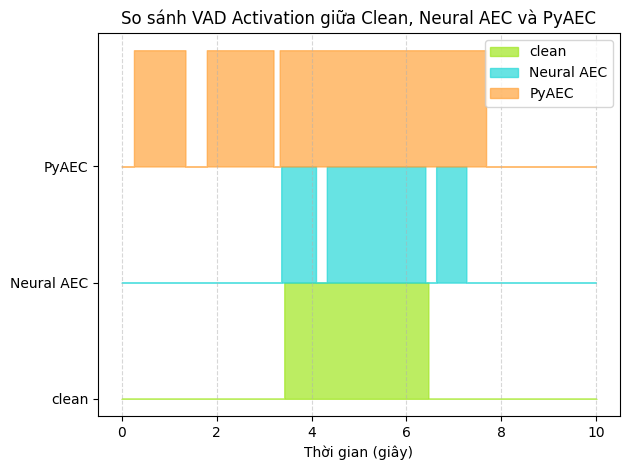

In [43]:
for i, (name, audio) in enumerate(outputs.items()):
    # Chạy VAD
    mask, ts = get_vad_mask(audio)
    
    # Tính F1, FPR, FNR (Nhóm A)
    min_len = min(len(gt_mask), len(mask))
    y_true, y_pred = gt_mask[:min_len], mask[:min_len]
    f1 = f1_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    Precision = tp / (tp + fp) if (tp+fp) > 0 else 1
    Recall = tp / (tp + fn) if (tp + fn) > 0 else 1
    
    # Tính Delay (Nhóm B)
    first_detect_ms = (ts[0]['start']/sr)*1000 if ts else 0
    delay = max(0, first_detect_ms - actual_start_time) if ts else "N/A"
    
    # Tính Convergence Time
    conv_time = calculate_convergence_time(x, audio, sr=sr)
    conv_series[name] = calculate_erle_series(x,audio,frame_size=160)
    conv_time_str = f"{conv_time:.2f}s" if conv_time is not None else ">5s"
    results[name] = {
        "F1": f1, "FPR": Precision, "FNR": Recall, 
        "Delay": delay, "Conv": conv_time_str
    }
    time_axis = np.arange(len(audio)) / sr
    plt.fill_between(time_axis, i, i + mask, color=colors[i % len(colors)], alpha=0.7, label=name)
    
plt.yticks(range(len(outputs)), outputs.keys())
plt.xlabel("Thời gian (giây)")
plt.title("So sánh VAD Activation giữa Clean, Neural AEC và PyAEC")
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()

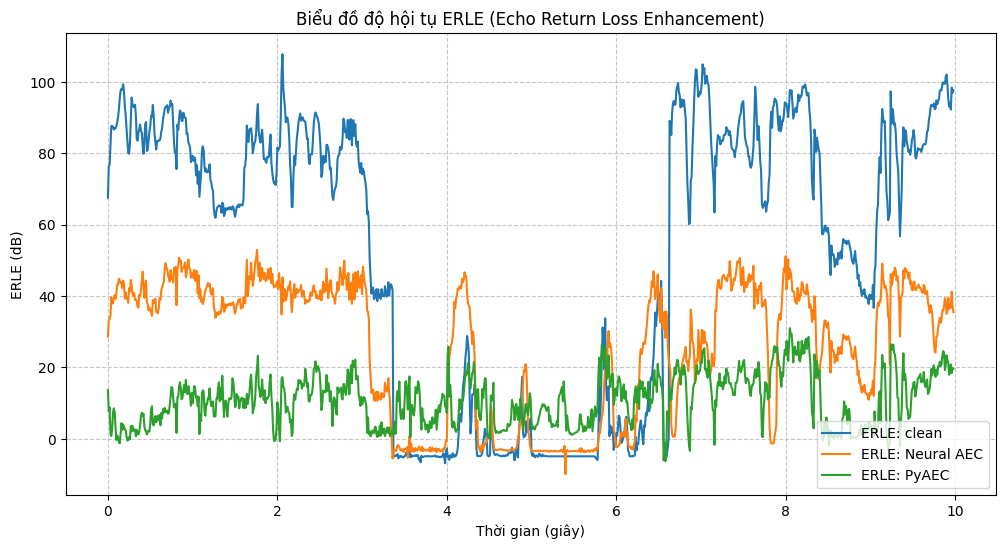

In [37]:
plt.figure(figsize=(12, 6))

# 2. Lặp qua kết quả của từng thuật toán để vẽ
for name, erle_values in conv_series.items():
    # Tính toán trục thời gian dựa trên frame_size (160) và sample rate (sr)
    # Mỗi điểm trong erle_values tương ứng với 1 frame
    frame_step = 160 / sr 
    time_axis_erle = np.arange(len(erle_values)) * frame_step
    
    # Vẽ đường ERLE
    plt.plot(time_axis_erle, erle_values, label=f'ERLE: {name}')

# 3. Trang trí đồ thị
plt.title('Biểu đồ độ hội tụ ERLE (Echo Return Loss Enhancement)')
plt.xlabel('Thời gian (giây)')
plt.ylabel('ERLE (dB)')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

In [41]:
# 6. In bảng kết quả
print(f"\n{'Thuật toán':<15} | {'F1':<6} | {'Precision':<6} | {'Recall':<6} | {'Delay(ms)':<10} | {'Conv Time'}")
print("-" * 75)
for name, m in results.items():
    delay_str = f"{m['Delay']:.2f}" if isinstance(m['Delay'], float) else m['Delay']
    print(f"{name:<15} | {m['F1']:6.2f} | {m['FPR']:6.2f} | {m['FNR']:6.2f} | {delay_str:<10} | {m['Conv']}")


Thuật toán      | F1     | Precision | Recall | Delay(ms)  | Conv Time
---------------------------------------------------------------------------
clean           |   1.00 |   1.00 |   1.00 | 0          | 0.00s
Neural AEC      |   0.85 |   0.80 |   0.90 | 0          | 0.00s
PyAEC           |   0.62 |   0.44 |   1.00 | 0          | 0.00s


In [ ]:
import torch
import torchaudio
import json
import os
from tqdm import tqdm

# 1. Tải model Silero VAD từ TorchHub
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model, utils = torch.hub.load(repo_or_dir='snakers4/silero-vad',
                              model='silero_vad',
                              force_reload=False)
(get_speech_timestamps, save_audio, read_audio, VADIterator, collect_chunks) = utils
model.to(device)

# 2. Cấu hình đường dẫn
input_folder = 'path/to/your/flac/folder'  # Thay đổi đường dẫn này
output_label_file = 'vad_labels.json'
sampling_rate = 16000 # Silero VAD hỗ trợ 8000 hoặc 16000

def process_vad():
    vad_results = {}

    # Duyệt từ 1 đến 300.000
    for i in tqdm(range(1, 300001), desc="Processing VAD"):
        file_name = f"{i:06d}.flac"
        file_path = os.path.join(input_folder, file_name)

        if not os.path.exists(file_path):
            continue

        try:
            # Load audio
            wav, sr = torchaudio.load(file_path)
            
            # Resample nếu cần (Silero yêu cầu 16kHz hoặc 8kHz)
            if sr != sampling_rate:
                resampler = torchaudio.transforms.Resample(sr, sampling_rate)
                wav = resampler(wav)

            # Chuyển về mono nếu là stereo
            if wav.shape[0] > 1:
                wav = torch.mean(wav, dim=0, keepdim=True)

            # Thực hiện VAD
            # Trả về list các dict: [{'start': ms, 'end': ms}, ...]
            speech_timestamps = get_speech_timestamps(wav, model, sampling_rate=sampling_rate)
            
            # Lưu kết quả (đơn vị là sample, bạn có thể chia cho sampling_rate để ra giây)
            vad_results[file_name] = speech_timestamps

        except Exception as e:
            print(f"Error processing {file_name}: {e}")

        # Backup kết quả mỗi 1000 file để tránh mất dữ liệu khi crash
        if i % 1000 == 0:
            with open(output_label_file, 'w', encoding='utf-8') as f:
                json.dump(vad_results, f, indent=4)

    # Lưu kết quả cuối cùng
    with open(output_label_file, 'w', encoding='utf-8') as f:
        json.dump(vad_results, f, indent=4)
    
    print(f"Hoàn thành! Kết quả được lưu tại {output_label_file}")

if __name__ == "__main__":
    process_vad()